In [ ]:
!pip install seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:

file_path = pd.read_csv(r'F:\CDC\SEMANTIC SEGMENTATION - Copy\training_tabular.csv')

In [ ]:
df= file_path.copy()


In [ ]:
#since id and date are not required for training the model , we will drop them

df.drop(['id'],inplace=True,axis=1)
df.drop(['date'] , axis = 1 , inplace = True)

In [ ]:
print(df.head())

    price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  268643         4       2.25         1810      9240     2.0           0   
1  245000         3       2.50         1600      2788     2.0           0   
2  200000         4       2.50         1720      8638     2.0           0   
3  352499         2       2.25         1240       705     2.0           0   
4  232000         3       2.00         1280     13356     1.0           0   

   view  condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
0     0          3      7        1810              0      1961             0   
1     0          4      7        1600              0      1992             0   
2     0          3      8        1720              0      1994             0   
3     0          3      7        1150             90      2009             0   
4     0          3      7        1280              0      1994             0   

   zipcode      lat     long  sqft_living15  sqft_lot15 

price            1.000000
sqft_living      0.700933
grade            0.664266
sqft_above       0.602648
sqft_living15    0.581781
bathrooms        0.525487
view             0.390534
sqft_basement    0.320301
lat              0.310008
bedrooms         0.304454
floors           0.251428
waterfront       0.245221
yr_renovated     0.133075
sqft_lot         0.088526
sqft_lot15       0.076060
yr_built         0.048307
condition        0.031333
long             0.024279
zipcode         -0.054517
Name: price, dtype: float64


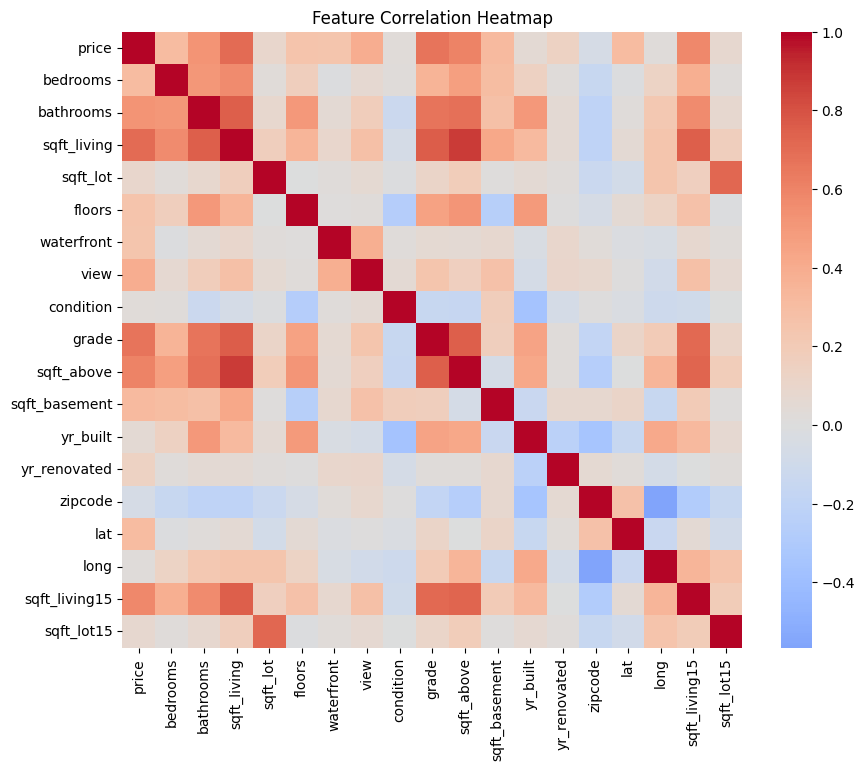

In [ ]:
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print(corr)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
df["basement_ratio"] = df["sqft_basement"] / (df["sqft_living"] + 1)
df.drop(columns=["sqft_above", "sqft_basement"], inplace=True)

In [ ]:
df["living_vs_neighbors"] = df["sqft_living"] / (df["sqft_living15"] + 1)
df["lot_vs_neighbors"] = df["sqft_lot"] / (df["sqft_lot15"] + 1)

In [ ]:
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)
df.drop(columns=["yr_renovated"], inplace=True)

In [ ]:
df["has_view"] = (df["view"] > 0).astype(int)

In [ ]:
df["log_price"] = np.log1p(df["price"])
df["sqft_living"]=np.log1p(df['sqft_living'])

In [ ]:
df["log_sqft_lot"] = np.log1p(df["sqft_lot"])
df["log_sqft_lot15"] = np.log1p(df["sqft_lot15"])
df["log_sqft_living15"] = np.log1p(df["sqft_living15"])

In [ ]:
df['diff_year']= df['yr_built']- df['is_renovated']

In [ ]:
zip_df = df.groupby('zipcode').agg(np.mean)
zip_df.reset_index(inplace=True)
zip_df.head()

C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_38104\814087717.py:1: FutureWarning: The provided callable <function mean at 0x0000017F7F56BB50> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  zip_df = df.groupby('zipcode').agg(np.mean)


,zipcode,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,basement_ratio,living_vs_neighbors,lot_vs_neighbors,is_renovated,has_view,log_price,log_sqft_lot,log_sqft_lot15,log_sqft_living15,diff_year
0,98001,2.797596e+05,3.391144,2.019373,7.495453,13117.756458,1.428044,0.000000,0.136531,3.354244,...,0.082158,1.045100,1.187080,0.022140,0.051661,12.490359,9.249671,9.158885,7.479771,1980.394834
1,98002,2.386830e+05,3.344371,1.836093,7.363718,7534.682119,1.347682,0.000000,0.013245,3.801325,...,0.054168,1.152912,1.065552,0.013245,0.006623,12.358541,8.836868,8.799052,7.263934,1967.079470
2,98003,2.905892e+05,3.349754,2.075123,7.503650,10506.147783,1.312808,0.000000,0.221675,3.403941,...,0.123743,1.022805,1.070493,0.009852,0.113300,12.531108,9.153204,9.117058,7.501402,1976.344828
3,98004,1.328961e+06,3.846809,2.512766,7.866243,12901.974468,1.429787,0.004255,0.289362,3.519149,...,0.150805,1.111341,1.015350,0.097872,0.144681,13.990469,9.354071,9.358618,7.832865,1969.923404
4,98005,8.116100e+05,3.888000,2.450000,7.833369,20496.744000,1.248000,0.000000,0.096000,3.672000,...,0.188982,1.058671,1.114397,0.032000,0.032000,13.560703,9.642027,9.580484,7.813171,1969.624000


In [ ]:
df['count'] = 1
count_zip = df.groupby('zipcode').sum()
count_zip.reset_index(inplace=True)
count_zip = count_zip[['zipcode', 'count']]
df.drop(['count'], axis = 1, inplace=True)
count_zip.head()

,zipcode,count
0,98001,271
1,98002,151
2,98003,203
3,98004,235
4,98005,125


In [ ]:
zip_df = pd.merge(zip_df, count_zip, how='left', on=['zipcode'])
zip_df.head()

,zipcode,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,living_vs_neighbors,lot_vs_neighbors,is_renovated,has_view,log_price,log_sqft_lot,log_sqft_lot15,log_sqft_living15,diff_year,count
0,98001,2.797596e+05,3.391144,2.019373,7.495453,13117.756458,1.428044,0.000000,0.136531,3.354244,...,1.045100,1.187080,0.022140,0.051661,12.490359,9.249671,9.158885,7.479771,1980.394834,271
1,98002,2.386830e+05,3.344371,1.836093,7.363718,7534.682119,1.347682,0.000000,0.013245,3.801325,...,1.152912,1.065552,0.013245,0.006623,12.358541,8.836868,8.799052,7.263934,1967.079470,151
2,98003,2.905892e+05,3.349754,2.075123,7.503650,10506.147783,1.312808,0.000000,0.221675,3.403941,...,1.022805,1.070493,0.009852,0.113300,12.531108,9.153204,9.117058,7.501402,1976.344828,203
3,98004,1.328961e+06,3.846809,2.512766,7.866243,12901.974468,1.429787,0.004255,0.289362,3.519149,...,1.111341,1.015350,0.097872,0.144681,13.990469,9.354071,9.358618,7.832865,1969.923404,235
4,98005,8.116100e+05,3.888000,2.450000,7.833369,20496.744000,1.248000,0.000000,0.096000,3.672000,...,1.058671,1.114397,0.032000,0.032000,13.560703,9.642027,9.580484,7.813171,1969.624000,125


In [ ]:
df.bedrooms.value_counts()

bedrooms
3     7380
4     5128
2     2098
5     1213
6      197
1      142
7       26
8        9
0        8
9        5
10       2
33       1
Name: count, dtype: int64

In [ ]:
df.replace({'bedrooms': {33: 3}}, inplace=True)

In [ ]:
df.grade.value_counts()

grade
7     6761
8     4563
9     1943
6     1511
10     861
11     286
5      183
12      63
4       24
13      10
3        3
1        1
Name: count, dtype: int64

In [ ]:
bins = [0, 3, 6, 7, 10, 13]
labels = [
    "Very Poor",
    "Below Average",
    "Average",
    "Good",
    "Excellent"
]

df["grade_binned"] = pd.cut(
    df["grade"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [ ]:
df["grade_binned"].value_counts()


grade_binned
Good             7367
Average          6761
Below Average    1718
Excellent         359
Very Poor           4
Name: count, dtype: int64

In [ ]:
grade_mapping = {
    "Very Poor": 1,
    "Below Average": 2,
    "Average": 3,
    "Good": 4,
    "Excellent": 5
}

df["grade_binned_encoded"] = df["grade_binned"].map(grade_mapping)



In [ ]:
df.drop(['grade_binned'], axis=1, inplace=True)

In [ ]:
df.corr()["price"].sort_values(ascending=False)

price                   1.000000
log_price               0.893444
grade                   0.664266
sqft_living             0.610556
sqft_living15           0.581781
log_sqft_living15       0.541223
bathrooms               0.525487
grade_binned_encoded    0.520949
view                    0.390534
has_view                0.355841
bedrooms                0.313804
lat                     0.310008
living_vs_neighbors     0.298307
floors                  0.251428
waterfront              0.245221
log_sqft_lot            0.157974
log_sqft_lot15          0.143926
basement_ratio          0.138134
is_renovated            0.132729
sqft_lot                0.088526
sqft_lot15              0.076060
yr_built                0.048307
diff_year               0.047332
lot_vs_neighbors        0.039233
condition               0.031333
long                    0.024279
zipcode                -0.054517
Name: price, dtype: float64

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
# ---------------------------------------------------
# Model Zoo
# ---------------------------------------------------
import joblib



def train_and_compare_models(X_train, X_test, y_train, y_test):
    models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),

    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=10))
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# ---------------------------------------------------
# Training + Evaluation
# ---------------------------------------------------

    results = []

    for name, model in models.items():

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        if name=="XGBoost":
            joblib.dump(model, "xgb_model.pkl")


        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2 Score": r2
        })

    # ---------------------------------------------------
    # Results Table
    # ---------------------------------------------------

    results_df = pd.DataFrame(results).sort_values(
        by="RMSE"
    ).reset_index(drop=True)

    print(results_df)


## without encodings

In [ ]:
FEATURES = [
    "bedrooms", "bathrooms", "floors",
    "condition", "grade",
    "waterfront", "has_view",
    "living_vs_neighbors", "lot_vs_neighbors",
    "basement_ratio",
    "is_renovated","zipcode", "log_sqft_lot", "log_sqft_lot15", "log_sqft_living15", 'lat'
]

X = df[FEATURES]
y = df["log_price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45
)

In [ ]:
train_and_compare_models(X_train, X_test, y_train, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1922
[LightGBM] [Info] Number of data points in the train set: 12967, number of used features: 16
[LightGBM] [Info] Start training from score 13.047260
               Model      RMSE       MAE  R2 Score
0           LightGBM  0.170358  0.124127  0.894307
1            XGBoost  0.171023  0.124574  0.893480
2      Random Forest  0.191584  0.137995  0.866327
3  Gradient Boosting  0.192828  0.142833  0.864586
4      KNN Regressor  0.227253  0.166472  0.811920
5      Decision Tree  0.236812  0.174720  0.795765
6  Linear Regression  0.258869  0.200868  0.755947
7   Ridge Regression  0.258870  0.200868  0.755946
8   Lasso Regression  0.259060  0.201078  0.755586


## after encoding the labels

In [ ]:
df1=df.copy()


dum_feat = df1[['bedrooms', 'bathrooms', 'floors', 'condition', 'grade','zipcode']]
dum_index = dum_feat.columns
# To prevent what they call the dummy variable trap (related to multicollinearity), drop one of the dummy variable, as well as  the original categorical variable used in creating the dummy variables
df_dum = pd.get_dummies(data=dum_feat, columns=dum_index, drop_first=True, prefix=['bdr', 'bth',
 'flr', 'cnd', 'grd','zip'])
df_dum.head()

,bdr_1,bdr_2,bdr_3,bdr_4,bdr_5,bdr_6,bdr_7,bdr_8,bdr_9,bdr_10,...,zip_98146,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'yr_built', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'basement_ratio',
       'living_vs_neighbors', 'lot_vs_neighbors', 'is_renovated', 'has_view',
       'log_price', 'log_sqft_lot', 'log_sqft_lot15', 'log_sqft_living15',
       'diff_year', 'grade_binned_encoded'],
      dtype='object')

In [ ]:
FEATURES = [
    "waterfront", "has_view",
    "living_vs_neighbors", "lot_vs_neighbors",'basement_ratio',
    "is_renovated","zipcode", "log_sqft_lot", "log_sqft_lot15", "log_sqft_living15","sqft_living",
    'lat'
]





X = pd.concat(
    [df[FEATURES], df_dum],
    axis=1
)

y = df["log_price"]

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=45
)
train_and_compare_models(X_train, X_test, y_train, y_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2329
[LightGBM] [Info] Number of data points in the train set: 12967, number of used features: 118
[LightGBM] [Info] Start training from score 13.047260
               Model      RMSE       MAE  R2 Score
0            XGBoost  0.167885  0.122092  0.897353
1           LightGBM  0.168243  0.122613  0.896915
2   Ridge Regression  0.179167  0.133018  0.883093
3  Linear Regression  0.179221  0.133035  0.883023
4   Lasso Regression  0.179534  0.133248  0.882613
5      Random Forest  0.189053  0.135317  0.869836
6  Gradient Boosting  0.192838  0.142227  0.864572
7      KNN Regressor  0.231440  0.167220  0.804925
8      Decision Tree  0.237540  0.171388  0.794507


## trying out optimization techniques with RFECV

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline

In [ ]:


# =====================================================
# 1. RFECV + LINEAR REGRESSION
# =====================================================

# ---- Scale data FIRST (outside RFECV)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
)

# ---- RFECV with BARE LinearRegression
rfecv_lr = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rfecv_lr.fit(X_train_scaled, y_train)

# Selected features
X_train_lr_sel = X_train_scaled.loc[:, rfecv_lr.support_]
X_test_lr_sel  = X_test_scaled.loc[:, rfecv_lr.support_]

# ---- Final LR model
lr_final = LinearRegression()
lr_final.fit(X_train_lr_sel, y_train)

y_pred_lr = lr_final.predict(X_test_lr_sel)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# =====================================================
# 2. RFECV + RANDOM FOREST (CORRECT WAY)
# =====================================================

rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rfecv_rf = RFECV(
    estimator=rf_base,
    step=1,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rfecv_rf.fit(X_train, y_train)

# Selected features
X_train_rf_sel = X_train.loc[:, rfecv_rf.support_]
X_test_rf_sel  = X_test.loc[:, rfecv_rf.support_]

# ---- Final RF model
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_rf_sel, y_train)

y_pred_rf = rf_final.predict(X_test_rf_sel)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# =====================================================
# 3. FINAL COMPARISON TABLE
# =====================================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression + RFECV",
        "Random Forest + RFECV"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ],
    "Selected Features": [
        X_train_lr_sel.shape[1],
        X_train_rf_sel.shape[1]
    ]
}).sort_values("RMSE").reset_index(drop=True)

print(results)


                       Model      RMSE  R2 Score  Selected Features
0  Linear Regression + RFECV  0.179974  0.882038                114
1      Random Forest + RFECV  0.193303  0.863918                 93


In [ ]:
#save the cleaned features

FEATURES = [
    "waterfront", "has_view",
    "living_vs_neighbors", "lot_vs_neighbors",
    "basement_ratio",
    "is_renovated", "zipcode",
    "log_sqft_lot", "log_sqft_lot15",
    "log_sqft_living15", "log_sqft_living",
    "lat"
]

X = pd.concat(
    [df[FEATURES], df_dum],
    axis=1
)

y = df["log_price"]


cleaned_df = pd.concat([X, y], axis=1)
cleaned_df.to_csv("cleaned_data.csv", index=False)


## predicting for test data

In [ ]:
test_df= pd.read_csv(r'F:\CDC\SEMANTIC SEGMENTATION - Copy\segmentation_final\test2(test(1)) (1).csv')
fl=test_df.copy()

In [ ]:
fl.drop(['id'],inplace=True,axis=1)
fl.drop(['date'] , axis = 1 , inplace = True)
fl["basement_ratio"] = fl["sqft_basement"] / (fl["sqft_living"] + 1)
fl.drop(columns=["sqft_above", "sqft_basement"], inplace=True)
fl["is_renovated"] = (fl["yr_renovated"] > 0).astype(int)
fl.drop(columns=["yr_renovated"], inplace=True)
fl["has_view"] = (fl["view"] > 0).astype(int)
fl["log_sqft_living"]=np.log1p(fl['sqft_living'])
fl["log_sqft_lot"] = np.log1p(fl["sqft_lot"])
fl["log_sqft_lot15"] = np.log1p(fl["sqft_lot15"])
fl["log_sqft_living15"] = np.log1p(fl["sqft_living15"])
zip_df = fl.groupby('zipcode').agg(np.mean)
zip_df.reset_index(inplace=True)
fl['count'] = 1
count_zip = fl.groupby('zipcode').sum()
count_zip.reset_index(inplace=True)
count_zip = count_zip[['zipcode', 'count']]
fl.drop(['count'], axis = 1, inplace=True)
zip_df = pd.merge(zip_df, count_zip, how='left', on=['zipcode'])
bins = [0, 3, 6, 7, 10, 13]
labels = [
    "Very Poor",
    "Below Average",
    "Average",
    "Good",
    "Excellent"
]

fl["grade_binned"] = pd.cut(
    fl["grade"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
grade_mapping = {
    "Very Poor": 1,
    "Below Average": 2,
    "Average": 3,
    "Good": 4,
    "Excellent": 5
}

fl["grade_binned_encoded"] = fl["grade_binned"].map(grade_mapping)

fl.drop(['grade_binned'], axis=1, inplace=True)

C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_38104\1440756690.py:12: FutureWarning: The provided callable <function mean at 0x0000017F7F56BB50> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  zip_df = fl.groupby('zipcode').agg(np.mean)


In [ ]:
fl["living_vs_neighbors"] = fl["sqft_living"] / (fl["sqft_living15"] + 1)
fl["lot_vs_neighbors"] = fl["sqft_lot"] / (fl["sqft_lot15"] + 1)

In [ ]:
df1=df.copy()


dum_feat = df1[['bedrooms', 'bathrooms', 'floors', 'condition', 'grade','zipcode']]
dum_index = dum_feat.columns
# To prevent what they call the dummy variable trap (related to multicollinearity), drop one of the dummy variable, as well as  the original categorical variable used in creating the dummy variables
df_dum = pd.get_dummies(data=dum_feat, columns=dum_index, drop_first=True, prefix=['bdr', 'bth',
 'flr', 'cnd', 'grd','zip'])



FEATURES = [
    "waterfront", "has_view",
    "living_vs_neighbors", "lot_vs_neighbors",'basement_ratio',
    "is_renovated","zipcode", "log_sqft_lot", "log_sqft_lot15", "log_sqft_living15","sqft_living",
    'lat'
]



X = pd.concat(
    [fl[FEATURES], df_dum],
    axis=1
)


In [ ]:
xgb_model = joblib.load("xgb_model.pkl")

In [ ]:

log_price_pred = xgb_model.predict(X)
price_pred = np.expm1(log_price_pred)

In [ ]:
submission = pd.DataFrame({
    "id": file_path["id"],
    "price": price_pred
})

submission.to_csv("predicted_onlytabular.csv", index=False)

print("✅ Predictions saved to predicted_onlytabular.csv")

✅ Predictions saved to predicted_onlytabular.csv
